In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ast
from datasets import load_dataset

# load data
ds = load_dataset("lukebarousse/data_jobs")
df = ds["train"].to_pandas()

# clean data
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"])
df["job_skills"] = df["job_skills"].apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

## Salary Distribution for Data Jobs in the US - Box Plot

1 - Filter dataframe for the top 6 most common data jobs and location 

In [51]:
# filter location and null salaries
df_us = df.loc[
    (df["job_country"] == "United States") & (df["salary_year_avg"].notna()),
    ["job_title_short", "salary_year_avg"]
].copy()

# find top 6 jobs
top_6_jobs = df_us["job_title_short"].value_counts().head(6).index

# filter df again for only the specified job titles
plot_df = df_us.loc[
    df_us["job_title_short"].isin(top_6_jobs),
    :
]
plot_df

,job_title_short,salary_year_avg
92,Data Engineer,120000.0
100,Data Scientist,228222.0
109,Data Analyst,89000.0
116,Data Scientist,114000.0
146,Data Engineer,129500.0
...,...,...
785563,Data Scientist,136400.0
785624,Data Engineer,139216.0
785641,Data Engineer,150000.0
785648,Data Scientist,221875.0


2 - Create list for boxplot sorting parameter based on the median salary

In [52]:
plot_order = plot_df.groupby("job_title_short").agg(median_salary=("salary_year_avg", "median")).sort_values(by="median_salary", ascending=False).index

3 - Plotting

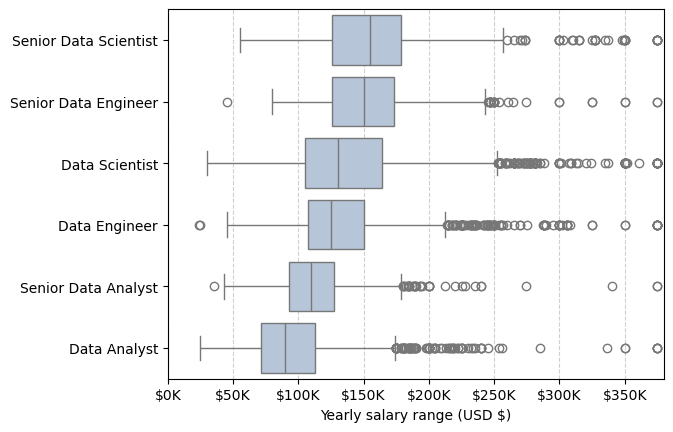

In [57]:
sns.boxplot(
    data=plot_df,
    x="salary_year_avg",
    y="job_title_short",
    order=plot_order,
    orient="h",
    color="lightsteelblue"
)

ax = plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))

plt.grid(True, linestyle="--", alpha=0.6)
plt.grid(False, axis="y")
plt.ylabel("")
plt.xlabel("Yearly salary range (USD $)")
plt.xlim(0, 380_000)
plt.show()

## Skills for Data Analysts (Senior included) - Salary vs. Popularity Comparison

1 - Filter and prepare data for plotting

In [60]:
# filter for data analysts only and select the necessary columns
df_da = df.loc[
    (df["job_title_short"].str.contains("Data Analyst")) & (df["salary_year_avg"].notna()) & (df["job_country"] == "United States"),
    ["job_title_short", "job_skills", "salary_year_avg"]
].copy()

# explode the dataframe
explode_df = df_da.explode("job_skills").reset_index(drop=True)
dataframes = []

# do aggregation
top_paying_skills = explode_df.groupby("job_skills").agg(
    median_yearly_salary=("salary_year_avg", "median")
).sort_values(by="median_yearly_salary", ascending=False).head(11)

# remove outlier
top_paying_skills = top_paying_skills.iloc[1:].reset_index()
dataframes.append(top_paying_skills)

# filter most request skills
most_in_demand_skills = explode_df["job_skills"].value_counts().head(10).reset_index()
median_salaries = []

# get the median yearly salary for each top skill
for skill in most_in_demand_skills["job_skills"]:
    median_salaries.append((explode_df.loc[explode_df["job_skills"] == skill,"salary_year_avg"].median()))

# add the salaries to each respective skill on the dataframe
most_in_demand_skills["median_yearly_salary"] = median_salaries
most_in_demand_skills = most_in_demand_skills.sort_values(by="median_yearly_salary", ascending=False)
dataframes.append(most_in_demand_skills)

2 - Plot both bar charts for comparison

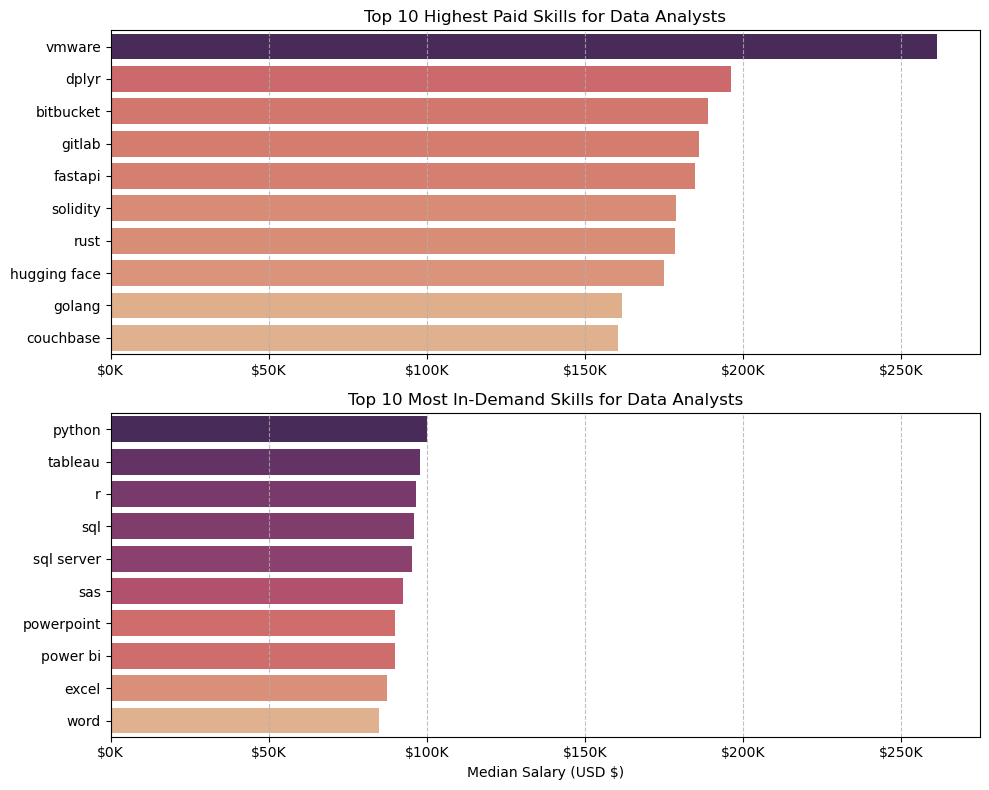

In [61]:
# create subplots
fig, ax = plt.subplots(nrows=2, figsize=(10, 8))

# add the data to each plot
for i, dframe in enumerate(dataframes):
    sns.barplot(
        data=dframe,
        x="median_yearly_salary",
        y="job_skills",
        ax=ax[i],
        hue="median_yearly_salary",
        palette="flare",
        legend=False
    )
    ax[i].set_xlim(0, 275_000)
    ax[i].grid(True, alpha=0.8, linestyle="--")
    ax[i].grid(False, axis="y")
    ax[i].set_ylabel("")
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x / 1000)}K"))


# format plot 1
ax[0].set_title("Top 10 Highest Paid Skills for Data Analysts")
ax[0].set_xlabel("")

# format plot 2
ax[1].set_title("Top 10 Most In-Demand Skills for Data Analysts")
ax[1].set_xlabel("Median Salary (USD $)")

fig.tight_layout()
plt.show()